# 03 — Feature Engineering and Validation Folds

Builds the predictor set for both tasks — fare regression and spike classification — and
prepares the validation folds the model notebooks will consume.

Two correctness questions dominate this notebook, and both are enforced in code rather than
left to care:

1. **What is knowable at prediction time?** Research question 2 asks whether a spike can be
   predicted *before* it happens. The prediction is therefore made standing at observation
   *t−1*, asking about *t*. Anything observed *at* *t* is unavailable and must not appear as
   a predictor.
2. **Does any flight appear in both training and test?** A single itinerary is searched
   repeatedly over weeks, so a careless split scores the model on trajectories it has already
   memorised.

Both have a guard that is verified to fire, not merely present.

In [1]:
import gc

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score

from flightprice.config import (
    PROCESSED_DIR, US_HOLIDAYS_2022, RANDOM_SEED, set_seeds,
    VALIDATION_N_SPLITS, VALIDATION_TEST_DAYS, VALIDATION_DATE_COL,
)
from flightprice.plotting import set_plot_style, save_fig, PALETTE
from flightprice.features.build import (
    build_feature_frame, FEATURE_COLUMNS, FEATURE_GROUPS,
    LEAKY_COLUMNS, assert_no_leaky_features,
)
from flightprice.evaluation.splitting import (
    rolling_origin_splits, chronological_split,
    assert_no_group_leakage, describe_folds,
)

set_seeds()
set_plot_style()
pd.set_option("display.width", 150)
pd.set_option("display.max_columns", 40)

In [2]:
labelled = pd.read_parquet(PROCESSED_DIR / "spikes_labelled.parquet")
features = build_feature_frame(labelled)

print(f"rows            : {len(features):,}")
print(f"features built  : {len(FEATURE_COLUMNS)}")
print(f"labelable rows  : {int(features.isLabelable.sum()):,}")
print(f"spike events    : {int(features.isSpikeEvent.sum()):,}")

rows            : 1,943,082
features built  : 32
labelable rows  : 1,389,510
spike events    : 108,495


## 1. What is knowable at prediction time

The columns divide three ways, and the division is what makes the spike results meaningful
rather than circular.

| Group | Availability | Examples |
|---|---|---|
| **Temporal / calendar** | Fixed when the flight was scheduled | booking horizon, day of week, holiday proximity, season |
| **Itinerary** | Constant along a trajectory | route, stops, airline, departure hour, duration |
| **Lagged** | Observed at *t−1* or earlier | `fareLag1`, `zLag1`, `seatsRemainingLag1`, rolling statistics |
| **Forbidden** | Observed *at t* — leaks the label | `totalFare`, `baseFare`, `spikeZ` |

`totalFare` at *t* is excluded because the label is a deterministic function of it: a spike is
declared when that fare exceeds its trailing mean by 2 trailing standard deviations. Handing
the model that fare would be handing it the answer. `baseFare` is the same quantity less
taxes and leaks just as directly.

The observed quantities that *are* useful — the fare and the seat count — therefore enter
lagged by one observation or more.

In [3]:
pd.DataFrame(
    [{"group": g, "n": len(cols), "features": ", ".join(cols)} for g, cols in FEATURE_GROUPS.items()]
).set_index("group")

,n,features
group,,
temporal,6,"daysBeforeDeparture, dayOfWeek, isWeekend, mon..."
calendar,3,"isHoliday, daysToNearestHoliday, isSummerSeason"
itinerary,8,"isNonStop, nSegments, isBasicEconomy, isRefund..."
lagged,12,"fareLag1, fareLag2, fareLag3, fareChangeLag1, ..."
categorical,3,"route, airline, departureTimeOfDay"


## 2. Calendar features

Day of week, month, season and holiday proximity. `daysToNearestHoliday` is signed distance
to the nearest of the four in-window federal holidays — fare effects straddle a holiday
rather than landing only on the day itself, so the distance carries more signal than a flag.

saved -> reports/figures/03_calendar_features.png


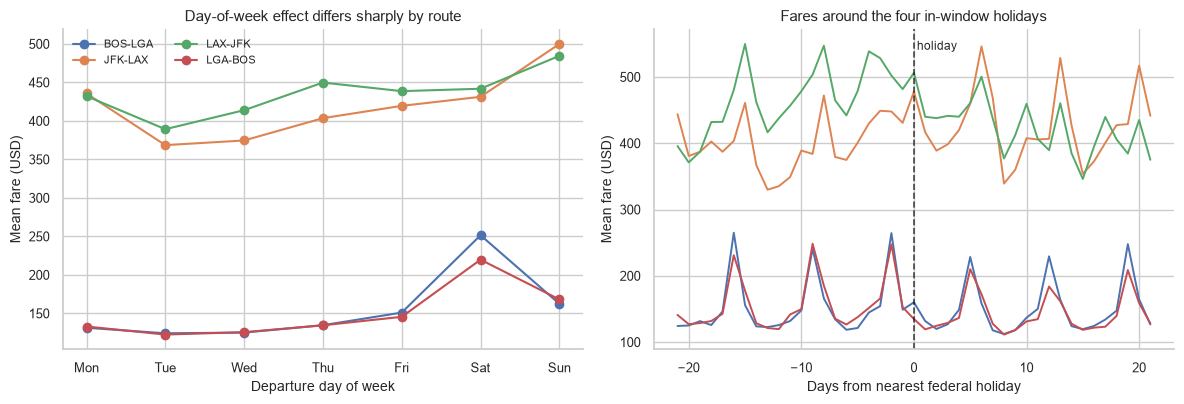

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

dow_names = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
dow = features.groupby(["dayOfWeek", "route"], observed=True)["totalFare"].mean().unstack()
for i, route in enumerate(dow.columns):
    axes[0].plot(dow.index, dow[route], marker="o", lw=1.5, label=route,
                 color=PALETTE[i % len(PALETTE)])
axes[0].set_xticks(range(7)); axes[0].set_xticklabels(dow_names)
axes[0].set_xlabel("Departure day of week"); axes[0].set_ylabel("Mean fare (USD)")
axes[0].set_title("Day-of-week effect differs sharply by route")
axes[0].legend(frameon=False, ncol=2, fontsize=8)

near = features[features.daysToNearestHoliday.between(-21, 21)]
hol = near.groupby(["daysToNearestHoliday", "route"], observed=True)["totalFare"].mean().unstack()
for i, route in enumerate(hol.columns):
    axes[1].plot(hol.index, hol[route], lw=1.4, label=route, color=PALETTE[i % len(PALETTE)])
axes[1].axvline(0, ls="--", lw=1.2, color="black", alpha=0.7)
axes[1].text(0, axes[1].get_ylim()[1]*0.97, " holiday", fontsize=8.5, va="top")
axes[1].set_xlabel("Days from nearest federal holiday"); axes[1].set_ylabel("Mean fare (USD)")
axes[1].set_title("Fares around the four in-window holidays")

fig.tight_layout()
save_fig(fig, "03_calendar_features")
plt.show()

The day-of-week pattern confirms the autocorrelation result from notebook 01 directly: the
short-haul routes swing hard into the weekend while the long-haul routes stay comparatively
flat. The holiday panel shows fares elevated in the days *before* a holiday rather than on it,
which is why the signed distance is preferred to a binary flag.

## 3. Itinerary features

Airline and departure time of day are included because research question 3 asks which factors
matter most and names airline explicitly. `segmentsAirlineName` and `segmentsDepartureTimeRaw`
hold one entry per leg joined by `||`; the operating carrier and scheduled departure of the
first leg are taken, with a flag for whether one carrier operates the whole itinerary.

Departure time of day is not in the original feature list from the project notes. It is added
because it is a well-established fare driver and is cheap to derive — noted here as a
deliberate addition rather than folded in silently.

In [5]:
summary = (
    features.groupby("airline", observed=True)
    .agg(rows=("totalFare", "size"), mean_fare=("totalFare", "mean"),
         median_fare=("totalFare", "median"), spike_rate=("isSpikeEvent", "mean"))
    .assign(share_pct=lambda d: d["rows"] / len(features) * 100,
            spike_rate=lambda d: d["spike_rate"] * 100)
    .round(2).sort_values("rows", ascending=False)
)
summary

,rows,mean_fare,median_fare,spike_rate,share_pct
airline,,,,,
American Airlines,753803,323.00,272.60,5.50,38.79
JetBlue Airways,438990,274.00,238.60,6.47,22.59
Delta,411183,266.94,212.70,5.48,21.16
United,184002,273.33,247.60,5.16,9.47
Alaska Airlines,155023,451.75,450.60,4.27,7.98
Cape Air,81,502.95,473.01,0.00,0.00


saved -> reports/figures/03_itinerary_features.png


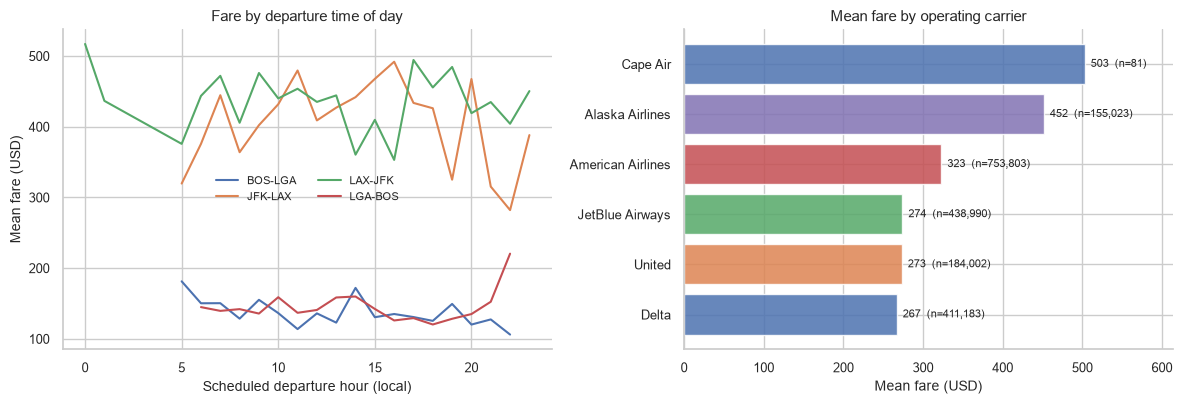

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

hourly = features.groupby(["departureHour", "route"], observed=True)["totalFare"].mean().unstack()
for i, route in enumerate(hourly.columns):
    axes[0].plot(hourly.index, hourly[route], lw=1.5, label=route, color=PALETTE[i % len(PALETTE)])
axes[0].set_xlabel("Scheduled departure hour (local)"); axes[0].set_ylabel("Mean fare (USD)")
axes[0].set_title("Fare by departure time of day")
axes[0].legend(frameon=False, ncol=2, fontsize=8)

top = summary.head(6).sort_values("mean_fare")
axes[1].barh(top.index.astype(str), top["mean_fare"],
             color=[PALETTE[i % len(PALETTE)] for i in range(len(top))], alpha=0.85)
for i, (v, n) in enumerate(zip(top["mean_fare"], top["rows"])):
    axes[1].text(v, i, f"  {v:,.0f}  (n={n:,})", va="center", fontsize=8)
axes[1].set_xlabel("Mean fare (USD)"); axes[1].set_title("Mean fare by operating carrier")
axes[1].margins(x=0.22)

fig.tight_layout()
save_fig(fig, "03_itinerary_features")
plt.show()

## 4. Lagged features

These are the observed quantities, shifted so that nothing from the predicted observation
enters. `zLag1` is worth noting: it is the same standardised quantity the label thresholds,
but measured one step back. It says how far the *previous* fare sat from its trailing
baseline, which is legitimately available and should be informative without being circular.

In [7]:
lagged = list(FEATURE_GROUPS["lagged"])
lab = features[features.isLabelable]

pd.DataFrame({
    "null_%": (lab[lagged].isna().mean() * 100).round(3),
    "mean": lab[lagged].mean().round(2),
    "std": lab[lagged].std().round(2),
})

,null_%,mean,std
fareLag1,0.0,303.07,228.59
fareLag2,0.0,301.87,228.57
fareLag3,0.0,300.62,228.30
fareChangeLag1,0.0,1.20,77.65
fareChangeLag2,0.0,1.25,77.10
fareAccel,0.0,-0.05,123.24
zLag1,0.0,0.19,1.19
seatsRemainingLag1,0.0,6.44,2.23
seatsChangeLag1,0.0,-0.03,1.93
rollMean,0.0,298.89,216.86


No nulls among the lagged features on labelable rows. This follows from the labelling rule
rather than luck: an observation is only labelable once it has at least five prior
observations behind it, which guarantees lags one to three exist.

## 5. Leakage audit

The guard is only worth having if it fires. Both halves are checked: that the intended
feature set passes, and that a deliberately contaminated one is rejected.

In [8]:
assert_no_leaky_features(FEATURE_COLUMNS)
print(f"clean feature set of {len(FEATURE_COLUMNS)} columns accepted")
print(f"forbidden columns: {', '.join(sorted(LEAKY_COLUMNS))}")

try:
    assert_no_leaky_features(list(FEATURE_COLUMNS) + ["totalFare"])
    print("\nPROBLEM: the guard failed to fire")
except AssertionError as exc:
    print(f"\nguard fired as intended:\n  {exc}")

clean feature set of 32 columns accepted
forbidden columns: baseFare, isLabelable, isSpike, isSpikeEvent, spikeZ, totalFare

guard fired as intended:
  Leaky column(s) in the feature set: totalFare. The label is derived from totalFare at the predicted observation, so these reveal the answer. Use the lagged equivalents (fareLag1, zLag1) instead.


It is worth seeing what the guard prevents rather than taking it on trust. Below, the same
model is fitted twice on the first fold — once on the legitimate feature set, once with
`totalFare` added.

In [9]:
# Only labelable rows are modelled from here. The full frame is released to keep
# peak memory modest -- the encoded matrix, the fitted trees and the source frame
# would otherwise be resident simultaneously.
model_frame = features[features.isLabelable].reset_index(drop=True)
del features, labelled
gc.collect()

print(f"modelling frame: {len(model_frame):,} rows x {len(model_frame.columns)} cols "
      f"({model_frame.memory_usage(deep=True).sum()/1e9:.2f} GB)")

modelling frame: 1,389,510 rows x 47 cols (0.44 GB)


In [10]:
def encode(frame, cols):
    """Categorical columns to integer codes, everything to float32 for XGBoost."""
    out = frame[list(cols)].copy()
    for col in out.columns:
        if str(out[col].dtype) in {"category", "object", "string", "bool"}:
            out[col] = out[col].astype("category").cat.codes
    return out.astype("float32")


def fit_and_score(X, y, fold, label, n_estimators=300):
    Xtr, ytr = X[fold.train_mask], y[fold.train_mask]
    Xte, yte = X[fold.test_mask], y[fold.test_mask]
    spw = (ytr == 0).sum() / max((ytr == 1).sum(), 1)
    clf = xgb.XGBClassifier(n_estimators=n_estimators, max_depth=6, learning_rate=0.1,
                            tree_method="hist", scale_pos_weight=spw, n_jobs=-1,
                            eval_metric="logloss", random_state=RANDOM_SEED)
    clf.fit(Xtr, ytr)
    pred = clf.predict(Xte)
    prob = clf.predict_proba(Xte)[:, 1]
    scores = {"feature set": label, "precision": precision_score(yte, pred),
              "recall": recall_score(yte, pred), "F1": f1_score(yte, pred),
              "ROC AUC": roc_auc_score(yte, prob)}
    del Xtr, Xte, ytr, yte
    gc.collect()
    return scores, clf


folds = rolling_origin_splits(
    model_frame, n_splits=VALIDATION_N_SPLITS,
    test_days=VALIDATION_TEST_DAYS, date_col=VALIDATION_DATE_COL,
)
fold = folds[0]

# Encoded once and reused. The leaky variant adds a column in place rather than
# building a second full copy.
X = encode(model_frame, FEATURE_COLUMNS)
y = model_frame["isSpikeEvent"].astype(int)
print(f"design matrix: {X.shape}  ({X.memory_usage(deep=True).sum()/1e6:.0f} MB)")

design matrix: (1389510, 32)  (178 MB)


In [11]:
legit, clf_legit = fit_and_score(X, y, fold, f"legitimate ({len(FEATURE_COLUMNS)})")

X["totalFare"] = model_frame["totalFare"].astype("float32")
leaky, _ = fit_and_score(X, y, fold, "with totalFare (LEAKY)")
X.drop(columns="totalFare", inplace=True)
gc.collect()

pd.DataFrame([legit, leaky]).set_index("feature set").round(3)

,precision,recall,F1,ROC AUC
feature set,,,,
legitimate (32),0.333,0.465,0.388,0.815
with totalFare (LEAKY),0.747,0.958,0.840,0.997


The contaminated model scores near-perfectly. That is the signature of leakage, not of a good
model: the label is a deterministic function of `totalFare`, so a tree only has to recover the
threshold. Anyone reading a result like this in a dissertation should immediately suspect
exactly this mistake — which is why `assert_no_leaky_features` is called before every fit
rather than relied upon as a convention.

The legitimate figures are the honest baseline: modest, and consistent with a genuinely hard
problem.

## 6. Validation folds

Folds come from `flightprice.evaluation.splitting` using the parameters committed in
`config.py`. The split is taken on **departure date**, so whole trajectories fall on one side.

In [12]:
describe_folds(model_frame, folds)

,train_start,train_end,test_start,test_end,train_rows,test_rows,train_flights,test_flights,test_positives,test_pos_rate_%
fold,,,,,,,,,,
1,2022-04-22,2022-08-03,2022-08-04,2022-08-17,657386,143546,33679,6015,9621,6.70
2,2022-04-22,2022-08-17,2022-08-18,2022-08-31,800932,161474,39694,5856,11347,7.03
3,2022-04-22,2022-08-31,2022-09-01,2022-09-14,962406,163033,45550,6491,12159,7.46
4,2022-04-22,2022-09-14,2022-09-15,2022-09-28,1125439,147128,52041,5962,11774,8.00
5,2022-04-22,2022-09-28,2022-09-29,2022-10-12,1272567,116943,58003,5298,10425,8.91


In [13]:
assert_no_group_leakage(model_frame, folds, group_col="legId")
print(f"{len(folds)} folds: no legId appears in both train and test")

# The same check on a searchDate split, to confirm it is capable of failing.
bad = rolling_origin_splits(model_frame, n_splits=3, test_days=VALIDATION_TEST_DAYS,
                            date_col="searchDate")
try:
    assert_no_group_leakage(model_frame, bad, group_col="legId")
    print("PROBLEM: the group-leakage guard failed to fire")
except AssertionError as exc:
    print(f"guard fired on a searchDate split, as intended:\n  {exc}")

5 folds: no legId appears in both train and test


guard fired on a searchDate split, as intended:
  Fold 1: 11,943 legId value(s) appear in both train and test. Split on departure date, not search date.


Both guards behave correctly: the departure-date folds are clean, and the check demonstrably
fails on a search-date split rather than passing everything indiscriminately.

## 7. Does the feature set carry signal?

A diagnostic, not a result — one model on one fold, untuned. Its purpose is to confirm the
features are informative before three model families are built on them. The model comparison
proper runs across all folds in the notebooks that follow.

saved -> reports/figures/03_feature_importance.png


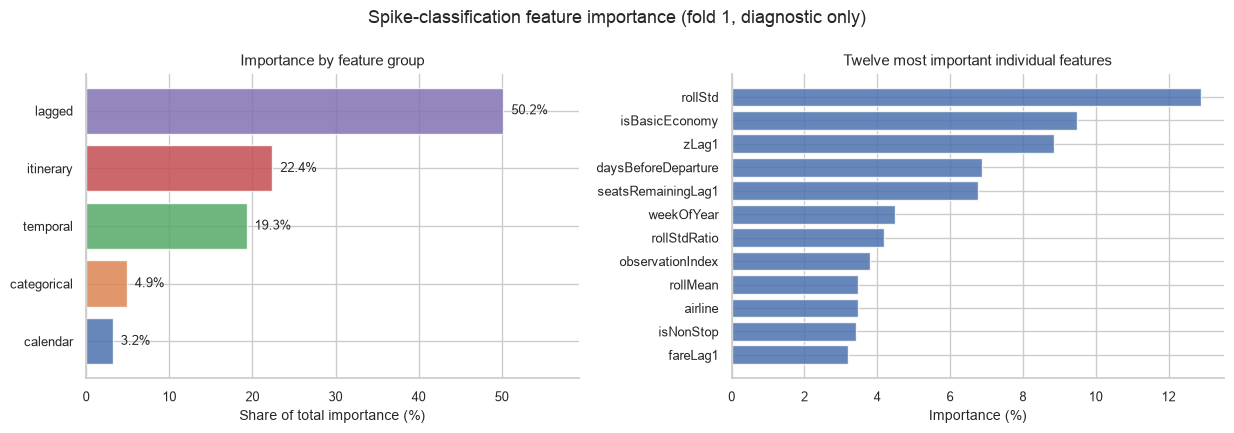

In [14]:
importance = pd.Series(clf_legit.feature_importances_, index=list(FEATURE_COLUMNS))
group_of = {col: grp for grp, cols in FEATURE_GROUPS.items() for col in cols}

by_group = (importance.groupby(importance.index.map(group_of)).sum()
            .sort_values(ascending=False) * 100).round(1)
top_features = (importance.sort_values(ascending=False).head(12) * 100).round(2)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))

axes[0].barh(by_group.index[::-1], by_group.values[::-1],
             color=[PALETTE[i % len(PALETTE)] for i in range(len(by_group))], alpha=0.85)
for i, v in enumerate(by_group.values[::-1]):
    axes[0].text(v, i, f"  {v:.1f}%", va="center", fontsize=9)
axes[0].set_xlabel("Share of total importance (%)")
axes[0].set_title("Importance by feature group")
axes[0].margins(x=0.18)

axes[1].barh(top_features.index[::-1], top_features.values[::-1], color=PALETTE[0], alpha=0.85)
axes[1].set_xlabel("Importance (%)")
axes[1].set_title("Twelve most important individual features")

fig.suptitle("Spike-classification feature importance (fold 1, diagnostic only)")
fig.tight_layout()
save_fig(fig, "03_feature_importance")
plt.show()

In [15]:
# Reuses the encoded matrix rather than rebuilding it per route, and trains on
# fold 1's training period only. 'route' is dropped because it is constant
# within each of these fits.
route_cols = [c for c in FEATURE_COLUMNS if c != "route"]
col_pos = [X.columns.get_loc(c) for c in route_cols]
in_train = (model_frame[VALIDATION_DATE_COL] < fold.test_start).to_numpy()

route_importance = {}
for route in model_frame.route.cat.categories:
    mask = (model_frame.route == route).to_numpy() & in_train
    if mask.sum() < 50_000:
        continue
    Xr = X.iloc[mask, col_pos]
    yr = y[mask]
    spw = (yr == 0).sum() / max((yr == 1).sum(), 1)
    clf = xgb.XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                            tree_method="hist", scale_pos_weight=spw, n_jobs=-1,
                            eval_metric="logloss", random_state=RANDOM_SEED)
    clf.fit(Xr, yr)
    route_importance[route] = pd.Series(clf.feature_importances_, index=route_cols)
    del Xr, yr, clf
    gc.collect()

comparison = (pd.DataFrame(route_importance) * 100).round(2)
comparison.loc[["dayOfWeek", "daysBeforeDeparture", "isWeekend", "departureHour",
                "isSummerSeason", "daysToNearestHoliday"]]

,BOS-LGA,JFK-LAX,LAX-JFK,LGA-BOS
dayOfWeek,2.41,1.83,1.56,2.05
daysBeforeDeparture,9.32,6.41,4.12,9.81
isWeekend,0.00,0.00,0.00,0.00
departureHour,1.25,1.33,1.70,1.24
isSummerSeason,0.00,0.00,0.00,0.00
daysToNearestHoliday,2.38,3.14,2.97,2.66


Three things stand out, and one of them contradicts an expectation carried from notebook 01.

**Booking horizon separates the route types strongly.** `daysBeforeDeparture` is worth roughly
**twice as much** on the short-haul routes (9.3, 9.8) as on the long-haul ones (6.4, 4.1).
That matches the booking curves measured in notebook 02 — short-haul fares climb about 65%
into departure while long-haul fares stay nearly flat — so the model is relying on the feature
exactly where it carries information.

**Day of week is higher on short-haul, but only modestly.** 2.41 and 2.05 against 1.83 and
1.56. Notebook 01 predicted from autocorrelation (lag-7 0.75 versus lag-1 0.46) that day of
week would matter *materially* more on the shuttle routes. For predicting *spike timing* that
hypothesis is only weakly supported — the separation is real but far smaller than the booking
horizon's. The autocorrelation finding described fare *levels*; it does not automatically
transfer to when a fare jumps. Whether it holds for the regression task is a separate question
and is tested there.

**`isWeekend` and `isSummerSeason` contribute nothing at all** — exactly zero on every route.
`isWeekend` is redundant: a tree can split `dayOfWeek >= 5` for itself. `isSummerSeason` is
more interesting, and the honest reading is that season governs the fare *level* rather than
the timing of a spike. Both are retained for now because the regression task may use them
differently, but if they stay at zero there they should be dropped and reported as such.

These figures come from one fold, one untuned model, and a gain-based importance that divides
credit between correlated features. They indicate where to look; they are not the
feature-importance result for research question 3.

## 8. Persist the modelling frame

In [16]:
id_cols = ["legId", "searchDate", "flightDate", "route",
           "startingAirport", "destinationAirport"]
label_cols = ["isSpike", "isSpikeEvent", "totalFare"]

keep = id_cols + [c for c in FEATURE_COLUMNS if c not in id_cols] + label_cols
model_ready = model_frame[keep]

out_path = PROCESSED_DIR / "model_frame.parquet"
model_ready.to_parquet(out_path, index=False)

print(f"wrote {len(model_ready):,} rows x {len(model_ready.columns)} cols -> {out_path.name} "
      f"({out_path.stat().st_size/1e6:.1f} MB)")

wrote 1,389,510 rows x 40 cols -> model_frame.parquet (55.8 MB)


This holds **labelable rows only** — those with enough trailing history for a spike verdict.
That is the correct population for the classification task and keeps the two tasks on one
consistent frame.

`totalFare` is retained deliberately: it is the **regression target** for research question 1
and the source of the spike label. It must never enter the predictor list, which is what
`assert_no_leaky_features` enforces.

If a later notebook wants the unrestricted population for fare regression, rebuild it with
`build_feature_frame()` from `spikes_labelled.parquet` — the function is deterministic and
takes a few seconds, so nothing is lost by not storing a second copy.

## Summary

| | |
|---|---|
| Features built | 32, across 5 groups |
| Rows | 1,943,082 (1,389,510 labelable) |
| Validation | 5 rolling-origin folds × 14 days, split on `flightDate` |
| Output | `data/processed/model_frame.parquet` |

**Established here:**

- **The feature set respects prediction-time availability.** `totalFare` and `seatsRemaining`
  at the predicted observation are excluded; both enter lagged. This is what keeps the spike
  results from being circular, since the label is a deterministic function of `totalFare`.
- **Both guards are verified to fire**, not merely present — `assert_no_leaky_features`
  rejects a contaminated feature list, and `assert_no_group_leakage` fails on a search-date
  split while passing on the departure-date folds.
- **Leakage would be easy to miss and impossible to ignore.** Adding `totalFare` lifts the
  model to a near-perfect score, which is exactly what a reader should treat as a red flag
  rather than a result.
- **The legitimate feature set carries real but modest signal** — ROC AUC 0.815 against 0.997
  for the leaked variant, consistent with a hard problem rather than a solved one.
- **Booking horizon matters about twice as much on short-haul as on long-haul**, matching the
  booking curves from notebook 02. Day of week separates the route types in the same direction
  but far more weakly than the notebook 01 autocorrelation implied — that finding described
  fare levels and does not transfer automatically to spike timing.
- **`isWeekend` and `isSummerSeason` score exactly zero** for spike classification. The first
  is redundant with `dayOfWeek`; the second suggests season drives fare level rather than
  spike timing. Both are kept pending the regression task, and should be dropped and reported
  if they stay at zero there.

**Next:** the model notebooks — SARIMA/SARIMAX, XGBoost and LSTM on JFK–LAX across all five
folds, then the same pipeline applied to BOS–LGA as a lighter single-split pass. Every fit
should call both guards first.